In [ ]:
import os
import warnings
os.environ['PYTENSOR_FLAGS'] = 'mode=NUMBA'
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")
import pytensor
import numba
warnings.filterwarnings("ignore", category=numba.NumbaPerformanceWarning)
import time
import numpy as np

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
sigma_noise = 20000
N = 20

np.random.seed(0)
x = np.random.uniform(500, 2500, N)
true_w = 200
noise = np.random.normal(0, sigma_noise, size=N)
y = x * true_w + noise

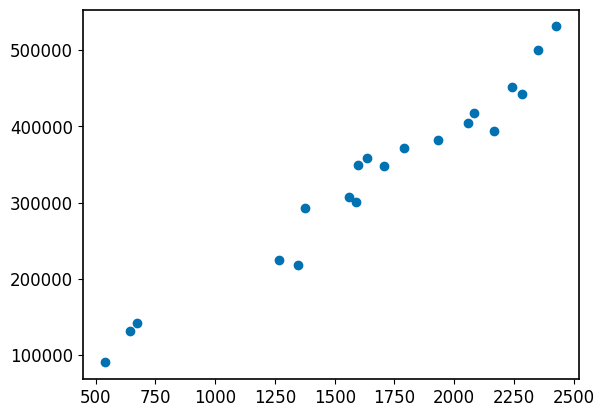

In [3]:
plt.scatter(x, y)
plt.show()

In [4]:
with pm.Model() as model:
    m = pm.Normal("m", mu=150, sigma=100)
    mu = m * x
    pm.Normal("obs", mu=mu, sigma=sigma_noise, observed=y)

    mcmc_samples = pm.sample(random_seed=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m]


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


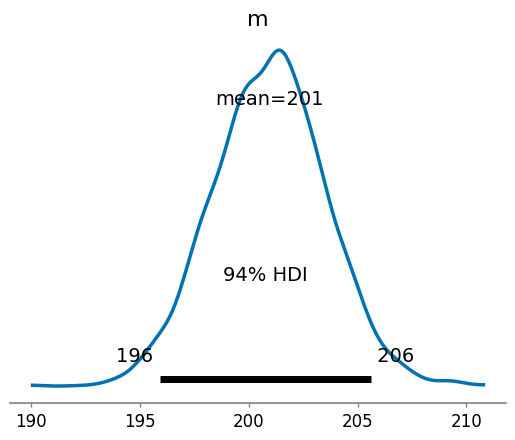

In [5]:
az.plot_posterior(mcmc_samples)
plt.show()

In [6]:
with pm.Model() as model:
    w = pm.Normal("w", mu=150, sigma=100)
    mu = w * x
    pm.Normal("obs", mu=mu, sigma=sigma_noise, observed=y)

    vi_approx = pm.fit(n=200_000)
    vi_samples = vi_approx.sample(1000, random_seed=0)

/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 234.27


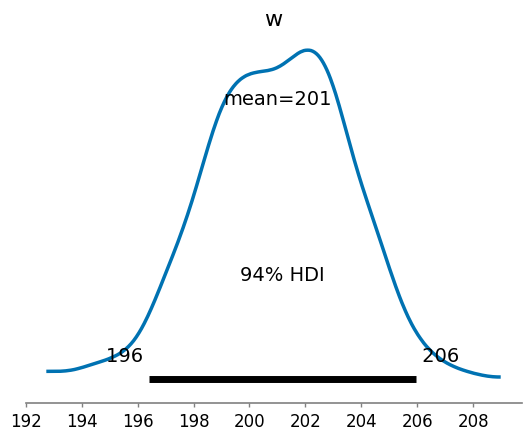

In [7]:
az.plot_posterior(vi_samples)
plt.show()

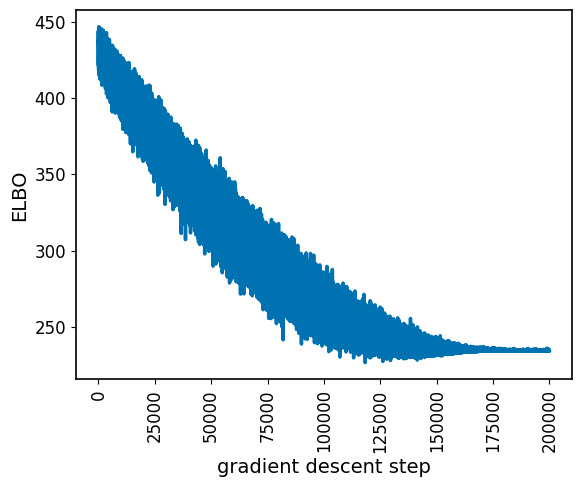

In [11]:
plt.plot(vi_approx.hist)
plt.xticks(rotation=90)
plt.xlabel("gradient descent step")
plt.ylabel("ELBO")
plt.show()